In [372]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [374]:
df = pd.read_csv("customer_shopping_behavior.csv")

### Summarising Dataset

In [377]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [379]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [381]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


### Column Formatting

In [384]:
# Formatting Column Names
df.columns = df.columns.str.lower()

In [386]:
df.columns = df.columns.str.replace(" ", "_")

In [388]:
df = df.rename(columns = {"purchase_amount_(usd)":"purchase_amount(usd)"})

In [390]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

### Replacing Null Values

In [393]:
# Check Null Values
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount(usd)       0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
dtype: int64

In [395]:
# Skewness
df["review_rating"].skew()

0.0013552919012980596

<Axes: xlabel='review_rating'>

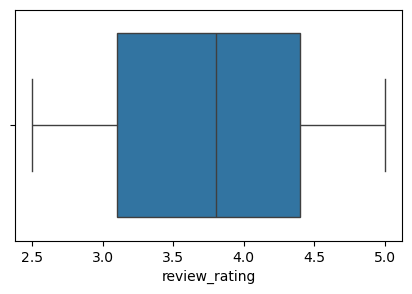

In [397]:
# Boxplot
plt.figure(figsize = (5, 3))
sns.boxplot(x=df["review_rating"])

<Axes: xlabel='review_rating', ylabel='Count'>

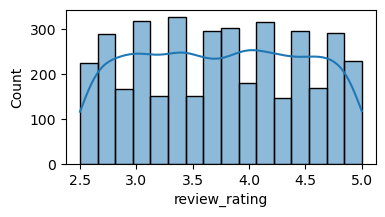

In [399]:
# Histogram
plt.figure(figsize = (4, 2))
sns.histplot(data = df, x = "review_rating", kde=True)

- We use the Mean to fill the Null value
- Because:
    1. Very low skewed data
    2. No heavy outliers
    3. Almost Symmetrical distribution

In [402]:
# Replace null values
df["review_rating"] = df.groupby("category")["review_rating"].transform(lambda x: x.fillna(x.mean()))

In [404]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount(usd)      0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

### Feature Engineering

In [407]:
# Create new column age_group
labels = ["Adult", "Young Adult", "Middle Age", "Senior"]
df["age_group"] = pd.qcut(df["age"], q = 4, labels = labels)

In [409]:
df[["age", "age_group" ]].head(10)

,age,age_group
0,55,Middle Age
1,19,Adult
2,50,Middle Age
3,21,Adult
4,45,Middle Age
5,46,Middle Age
6,63,Senior
7,27,Adult
8,26,Adult
9,57,Middle Age


In [411]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [413]:
df['frequency_of_purchases'] = df['frequency_of_purchases'].replace({
        'Fortnightly':'Bi-Weekly',
        'Every 3 Months':'Quarterly'
})

In [415]:
df['frequency_of_purchases'].unique()

array(['Bi-Weekly', 'Weekly', 'Annually', 'Quarterly', 'Monthly'],
      dtype=object)

In [417]:
# Create a column purchase_frequency_days
mapping = {
    'Bi-Weekly': 14, 
    'Weekly': 7, 
    'Annually': 365, 
    'Quarterly': 90, 
    'Monthly': 30
}

df["purchase_frequency_days"] = df['frequency_of_purchases'].map(mapping)

In [419]:
df[['frequency_of_purchases', "purchase_frequency_days"]].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Bi-Weekly,14
1,Bi-Weekly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


### Drop Unnecessary column 

In [422]:
df[["discount_applied", "promo_code_used"]]

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
...,...,...
3895,No,No
3896,No,No
3897,No,No
3898,No,No


In [424]:
(df["discount_applied"] == df["promo_code_used"]).all()

True

In [426]:
# Drop the column promo code used
df = df.drop("promo_code_used", axis=1)

In [428]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [433]:
# Download Cleaned Dataset
# df.to_csv("cleaned_customer_shopping_behavior.csv", index=False)

In [435]:
df1 = pd.read_csv("cleaned_customer_shopping_behavior.csv")

In [437]:
df1.head()

,customer_id,age,gender,item_purchased,category,purchase_amount(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Bi-Weekly,Middle Age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Bi-Weekly,Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Age,365


In [439]:
df1.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount(usd)       0
location                   0
size                       0
color                      0
season                     0
review_rating              0
subscription_status        0
shipping_type              0
discount_applied           0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
age_group                  0
purchase_frequency_days    0
dtype: int64